# Etap 1 - Zapoznanie się z danymi
## Dataset: Statystyki dotyczace punktualności linii lotniczych i przyczyny opóźnień
Zestaw danych zawierający informacje o opóźnieniach i wydajności lotów w Stanach Zjednoczonych pochodzących z RITA.
## Licencja
Zbiór danych publiczny
## Strona
https://www.transtats.bts.gov

## Spis treści
1. [Biblioteki](#biblioteki)
2. [Wyświetelenie informacji o csv](#wyswietlenie-informacji-o-csv)

## Biblioteki

In [1]:
import pandas as pd

## Wyświetlenie informacji o csv

In [2]:
def load_and_explore_csv(csv_path):
    print(f"Wczytuję plik: {csv_path}...")
    df = pd.read_csv(
        csv_path,
        skipinitialspace=True,
        quotechar='"'
    )
    df.columns = df.columns.str.strip()

    print("\n--- Pierwsze wiersze (head) ---")
    print(df.head())

    print("\n--- Informacje o DataFrame (info) ---")
    print(df.info())

    print("\n--- Statystyki opisowe (describe) ---")
    print(df.describe())

    print("\n--- Nazwy kolumn ---")
    print(df.columns.tolist())

if __name__ == "__main__":
    csv_file = "Airline_Delay_Cause.csv"
    load_and_explore_csv(csv_file)

Wczytuję plik: Airline_Delay_Cause.csv...

--- Pierwsze wiersze (head) ---
   year  month carrier       carrier_name airport  \
0  2024     10      OH  PSA Airlines Inc.     SGF   
1  2024     10      OH  PSA Airlines Inc.     SHV   
2  2024     10      OH  PSA Airlines Inc.     SRQ   
3  2024     10      OH  PSA Airlines Inc.     STL   
4  2024     10      OH  PSA Airlines Inc.     SYR   

                                        airport_name  arr_flights  arr_del15  \
0      Springfield, MO: Springfield-Branson National        119.0       16.0   
1                Shreveport, LA: Shreveport Regional         92.0       12.0   
2  Sarasota/Bradenton, FL: Sarasota/Bradenton Int...         31.0        3.0   
3      St. Louis, MO: St Louis Lambert International        115.0       15.0   
4       Syracuse, NY: Syracuse Hancock International         15.0        4.0   

   carrier_ct  weather_ct  ...  security_ct  late_aircraft_ct  arr_cancelled  \
0        5.50         0.0  ...          0.0  

# Etap 2 - Analiza danych i preprocessing
Zbadanie struktury danych i sprawdzenie wartości odstających oraz brakujących w tym identyfikacja najbardziej istotnych cech zbioru
## Spis treści
1. [Dask oraz inicjalizacja klienta Dask](#dask-oraz-inicjalizacja-klienta-dask)
2. [Wczytanie danych](#wczytanie-danych)
3. [Badanie struktury danych](#badanie-struktury-danych)
4. [Wczytanie danych](#wczytanie-danych)
5. [Wybór cech](#wybor-cech)
6. [Wartości odstające](#wartosci-odstajace)
7. [Wybór istotnych cech](#wybor-istotnych-cech)
8. [Zapis parquet](#zapis-parquet)

## Dask oraz inicjalizacja klienta Dask

In [3]:
import dask.dataframe as dd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

THIRD_POW_1024 = 1_073_741_824

In [4]:
from dask.distributed import LocalCluster, Client

cluster = LocalCluster(
    processes=True,
    n_workers=2,
    threads_per_worker=4,
    memory_limit='12GB',
)
client = Client(cluster)
client

C:\Users\kompu\PycharmProjects\ADZ\.venv1\lib\site-packages\distributed\node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 56041 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:56041/status,
Dashboard: http://127.0.0.1:56041/status,Workers: 2
Total threads: 8,Total memory: 22.35 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:56044,Workers: 2
Dashboard: http://127.0.0.1:56041/status,Total threads: 8
Started: Just now,Total memory: 22.35 GiB
Comm: tcp://127.0.0.1:56055,Total threads: 4
Dashboard: http://127.0.0.1:56056/status,Memory: 11.18 GiB
Nanny: tcp://127.0.0.1:56047,


2025-01-20 12:37:45,753 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle b19fc6c1e1e293ce9d97457cce436178 initialized by task ('shuffle-transfer-b19fc6c1e1e293ce9d97457cce436178', 1) executed on worker tcp://127.0.0.1:56058
2025-01-20 12:37:46,174 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle b19fc6c1e1e293ce9d97457cce436178 deactivated due to stimulus 'task-finished-1737373066.1727118'
2025-01-20 12:37:48,111 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle fecb327e71ddffbab33841c98c305cb2 initialized by task ('shuffle-transfer-fecb327e71ddffbab33841c98c305cb2', 2) executed on worker tcp://127.0.0.1:56058
2025-01-20 12:37:48,232 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle fecb327e71ddffbab33841c98c305cb2 deactivated due to stimulus 'task-finished-1737373068.2298584'
2025-01-20 12:37:50,105 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 18b6ca09be2e375e5bc4d2d1bbc24e03 initialized by task ('shuffle-transfer-18b6ca09be2e37

In [5]:
import os
import dask.dataframe as dd
def load_airline_data(folder='.',
                      filename='Airline_Delay_Cause.csv',
                      chunksize='128MB',
                      start_year=None,
                      end_year=None,
                      month=None):
    filepath = os.path.join(folder, filename)
    if not os.path.exists(filepath):
        print('Nie znaleziono pliku do wczytania')
        return None

    file_size = os.path.getsize(filepath)
    file_size_gb = file_size / (1024**3)
    print(f'Łączny rozmiar pliku: {file_size_gb:.2f} GB przed dekompresją.\n')

    ddf = dd.read_csv(filepath, blocksize=chunksize, assume_missing=True)

    if start_year is not None and end_year is not None:
        ddf = ddf[(ddf['year'] >= start_year) & (ddf['year'] <= end_year)]
    if month is not None:
        ddf = ddf[ddf['month'] == month]

    return ddf

In [6]:
ddf = load_airline_data(start_year=2003, end_year=2024)
ddf.info()

Łączny rozmiar pliku: 0.37 GB przed dekompresją.

<class 'dask_expr.DataFrame'>
Columns: 21 entries, year to late_aircraft_delay
dtypes: float64(17), string(4)

In [7]:
ddf.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024.0,10.0,OH,PSA Airlines Inc.,SGF,"Springfield, MO: Springfield-Branson National",119.0,16.0,5.50,0.0,...,0.0,6.90,0.0,0.0,1575.0,716.0,0.0,111.0,0.0,748.0
1,2024.0,10.0,OH,PSA Airlines Inc.,SHV,"Shreveport, LA: Shreveport Regional",92.0,12.0,4.56,0.0,...,0.0,1.52,0.0,0.0,372.0,174.0,0.0,166.0,0.0,32.0
2,2024.0,10.0,OH,PSA Airlines Inc.,SRQ,"Sarasota/Bradenton, FL: Sarasota/Bradenton Int...",31.0,3.0,0.40,0.0,...,0.0,2.57,7.0,0.0,86.0,9.0,0.0,1.0,0.0,76.0
3,2024.0,10.0,OH,PSA Airlines Inc.,STL,"St. Louis, MO: St Louis Lambert International",115.0,15.0,6.87,0.0,...,0.0,7.79,0.0,0.0,1186.0,351.0,0.0,7.0,0.0,828.0
4,2024.0,10.0,OH,PSA Airlines Inc.,SYR,"Syracuse, NY: Syracuse Hancock International",15.0,4.0,1.42,0.0,...,0.0,1.53,0.0,0.0,162.0,62.0,0.0,27.0,0.0,73.0


In [8]:
ddf = load_airline_data(start_year=2003, end_year=2024, month=10)
ddf.info()

Łączny rozmiar pliku: 0.37 GB przed dekompresją.

<class 'dask_expr.DataFrame'>
Columns: 21 entries, year to late_aircraft_delay
dtypes: float64(17), string(4)

In [9]:
ddf.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024.0,10.0,OH,PSA Airlines Inc.,SGF,"Springfield, MO: Springfield-Branson National",119.0,16.0,5.50,0.0,...,0.0,6.90,0.0,0.0,1575.0,716.0,0.0,111.0,0.0,748.0
1,2024.0,10.0,OH,PSA Airlines Inc.,SHV,"Shreveport, LA: Shreveport Regional",92.0,12.0,4.56,0.0,...,0.0,1.52,0.0,0.0,372.0,174.0,0.0,166.0,0.0,32.0
2,2024.0,10.0,OH,PSA Airlines Inc.,SRQ,"Sarasota/Bradenton, FL: Sarasota/Bradenton Int...",31.0,3.0,0.40,0.0,...,0.0,2.57,7.0,0.0,86.0,9.0,0.0,1.0,0.0,76.0
3,2024.0,10.0,OH,PSA Airlines Inc.,STL,"St. Louis, MO: St Louis Lambert International",115.0,15.0,6.87,0.0,...,0.0,7.79,0.0,0.0,1186.0,351.0,0.0,7.0,0.0,828.0
4,2024.0,10.0,OH,PSA Airlines Inc.,SYR,"Syracuse, NY: Syracuse Hancock International",15.0,4.0,1.42,0.0,...,0.0,1.53,0.0,0.0,162.0,62.0,0.0,27.0,0.0,73.0


## Badanie struktury danych

In [10]:
ddf.describe().compute()

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,199386.000000,199386.0,198798.000000,198750.000000,198798.000000,198798.000000,198798.000000,198798.000000,198798.000000,198798.000000,198798.000000,198798.000000,198798.000000,198798.000000,198798.000000,198798.000000,198798.000000
mean,2014.209503,10.0,372.289289,60.121902,17.951246,1.527465,20.310853,0.136040,20.181820,3.966016,0.596777,3292.963058,1088.404883,127.182356,847.084508,5.430839,1224.853500
std,6.557410,0.0,1022.528245,170.893759,42.207083,7.777540,77.278421,0.617381,62.269461,17.202987,2.722867,10099.524249,3135.324668,625.299015,3878.610920,27.666876,3831.343103
min,2003.000000,10.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2008.000000,10.0,58.000000,7.000000,2.420000,0.000000,1.080000,0.000000,1.000000,0.000000,0.000000,321.000000,113.000000,0.000000,36.000000,0.000000,53.000000
50%,2015.000000,10.0,118.000000,18.000000,6.650000,0.000000,4.170000,0.000000,4.460000,0.000000,0.000000,901.000000,342.000000,0.000000,142.000000,0.000000,256.000000
75%,2020.000000,10.0,264.000000,45.000000,16.270000,1.000000,12.430000,0.000000,13.430000,2.000000,0.000000,2357.000000,902.000000,70.000000,437.000000,0.000000,835.000000
max,2024.000000,10.0,21546.000000,4966.000000,1671.020000,617.360000,2797.940000,20.000000,1494.950000,711.000000,183.000000,260600.000000,117535.000000,35293.000000,140220.000000,855.000000,100423.000000


## Opis kolumn
| **Nazwa Kolumny**         | **Opis Kolumny**                                                                                                                                                                                                                                                                                  |
|---------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **year**                | Rok, format YYYY                                                                                                                                                                                                                                                                                |
| **month**               | Miesiąc, format MM (1-12)                                                                                                                                                                                                                                                                         |
| **carrier**             | Kod przypisany przez US DOT, który identyfikuje unikalnego przewoźnika lotniczego.                                                                                                                                                                                                               |
| **carrier_name**        | Nazwa przewoźnika: Unikalny przewoźnik definiowany jest jako podmiot posiadający oraz raportujący na podstawie tego samego certyfikatu DOT, niezależnie od kodu, nazwy czy spółki macierzystej.                                                                                          |
| **airport**             | Trójliterowy kod alfanumeryczny wydany przez U.S. Department of Transportation, stanowiący oficjalne oznaczenie lotniska.                                                                                                                                                                       |
| **airport_name**        | Nazwa miejsca, z którego operują statki powietrzne, zazwyczaj posiada pasy startowe, zaplecze konserwacyjne oraz często pełni funkcję terminala.                                                                                                                                               |
| **arr_flights**         | Loty przybywcze.                                                                                                                                                                                                                                                                                  |
| **arr_del15**           | Wskaźnik opóźnienia przybycia – 15 minut lub więcej. Opóźnienie przybycia to różnica między faktycznym czasem przylotu a planowanym czasem przylotu. Lot uznaje się za punktualny, gdy przylatuje z opóźnieniem krótszym niż 15 minut.                                                         |
| **carrier_ct**          | Liczba opóźnień spowodowanych przez przewoźnika (Carrier Count).                                                                                                                                                                                                                                  |
| **weather_ct**          | Liczba opóźnień spowodowanych przez warunki pogodowe (Weather Count).                                                                                                                                                                                                                              |
| **nas_ct**              | Liczba opóźnień spowodowanych przez system NAS (National Air System Count).                                                                                                                                                                                                                       |
| **security_ct**         | Liczba opóźnień spowodowanych przez kwestie bezpieczeństwa (Security Count).                                                                                                                                                                                                                       |
| **late_aircraft_ct**    | Liczba opóźnień spowodowanych przez opóźnienia samolotu (Late Aircraft Delay Count).                                                                                                                                                                                                              |
| **arr_cancelled**       | Lot odwołany.                                                                                                                                                                                                                                                                                     |
| **arr_diverted**        | Lot przekierowany.                                                                                                                                                                                                                                                                                |
| **arr_delay**           | Różnica w minutach między planowanym a rzeczywistym czasem przylotu. W przypadku wcześniejszych przylotów wartości są ujemne.                                                                                                                                                                      |
| **carrier_delay**       | Opóźnienie spowodowane przez przewoźnika, wyrażone w minutach.                                                                                                                                                                                                                                   |
| **weather_delay**       | Opóźnienie spowodowane przez warunki pogodowe, wyrażone w minutach.                                                                                                                                                                                                                               |
| **nas_delay**           | Opóźnienie spowodowane przez system NAS (National Air System Delay), wyrażone w minutach.                                                                                                                                                                                                          |
| **security_delay**      | Opóźnienie spowodowane przez kwestie bezpieczeństwa, wyrażone w minutach.                                                                                                                                                                                                                          |
| **late_aircraft_delay** | Opóźnienie spowodowane przez opóźnienie samolotu, wyrażone w minutach.                                                                                                                                                                                                                            |


In [11]:
import pandas as pd
def data_summary_airline(ddf):
    summary_data = []
    total_count = ddf.index.size.compute()

    for column in ddf.columns:
        dtype = str(ddf[column].dtype)
        non_null_count = ddf[column].count().compute()
        unique_count = ddf[column].nunique().compute()
        missing_count = total_count - non_null_count
        missing_percentage = (missing_count / total_count) * 100

        summary_data.append({
            'Column': column,
            'Data Type': dtype,
            'Non-Null Count': non_null_count,
            'Unique Count': unique_count,
            'Missing Count': missing_count,
            'Missing Percentage': missing_percentage
        })

    return pd.DataFrame(summary_data)


In [12]:
data_summary_airline(ddf)

,Column,Data Type,Non-Null Count,Unique Count,Missing Count,Missing Percentage
0,year,float64,199386,22,0,0.000000
1,month,float64,199386,1,0,0.000000
2,carrier,string,199386,37,0,0.000000
3,carrier_name,string,199386,50,0,0.000000
4,airport,string,199386,410,0,0.000000
5,airport_name,string,199386,433,0,0.000000
6,arr_flights,float64,198798,2721,588,0.294905
7,arr_del15,float64,198750,997,636,0.318979
8,carrier_ct,float64,198798,6142,588,0.294905
9,weather_ct,float64,198798,1615,588,0.294905


In [13]:
ddf = ddf.dropna()

In [14]:
def memory_usage_mb(ddf):
    return ddf.map_partitions(lambda df: df.memory_usage(deep=True).sum()).compute().sum() / (1024**2)

In [15]:
print(f"Rzeczywisty rozmiar ddf: {memory_usage_mb(ddf):.2f} MB)")

Rzeczywisty rozmiar ddf: 83.31 MB)


In [16]:
dtypes = {
    'year': 'int16',
    'month': 'int8',
    'carrier': 'category',
    'carrier_name': 'category',
    'airport': 'category',
    'airport_name': 'category',
    'arr_flights': 'float32',
    'arr_del15': 'float32',
    'carrier_ct': 'float32',
    'weather_ct': 'float32',
    'nas_ct': 'float32',
    'security_ct': 'float32',
    'late_aircraft_ct': 'float32',
    'arr_cancelled': 'float32',
    'arr_diverted': 'float32',
    'arr_delay': 'float32',
    'carrier_delay': 'float32',
    'weather_delay': 'float32',
    'nas_delay': 'float32',
    'security_delay': 'float32',
    'late_aircraft_delay': 'float32'
}

In [17]:
ddf = ddf.astype(dtypes)

In [18]:
print(f"Rzeczywisty rozmiar ddf po zmianie typów: {memory_usage_mb(ddf):.2f} MB)")

Rzeczywisty rozmiar ddf po zmianie typów: 14.91 MB)


## Wczytanie danych

In [19]:
ddf = load_airline_data(start_year=2003, end_year=2024)
ddf.info()

Łączny rozmiar pliku: 0.37 GB przed dekompresją.

<class 'dask_expr.DataFrame'>
Columns: 21 entries, year to late_aircraft_delay
dtypes: float64(17), string(4)

In [20]:
ddf = ddf.astype(dtypes)

In [21]:
ddf = ddf.dropna()

In [22]:
print(data_summary_airline(ddf))

                 Column Data Type  Non-Null Count  Unique Count  \
0                  year     int16         2349402            22   
1                 month      int8         2349402            12   
2               carrier  category         2349402            38   
3          carrier_name  category         2349402            51   
4               airport  category         2349402           422   
5          airport_name  category         2349402           446   
6           arr_flights   float32         2349402          7619   
7             arr_del15   float32         2349402          2401   
8            carrier_ct   float32         2349402         19990   
9            weather_ct   float32         2349402          5955   
10               nas_ct   float32         2349402         22527   
11          security_ct   float32         2349402          1213   
12     late_aircraft_ct   float32         2349402         24228   
13        arr_cancelled   float32         2349402           69

In [23]:
print(f"Rzeczywisty rozmiar ddf po zmianie typów i wstępnym czyszczeniu: {memory_usage_mb(ddf):.2f} MB")

Rzeczywisty rozmiar ddf po zmianie typów i wstępnym czyszczeniu: 172.84 MB


## Wybór Cech
Moim celem jest przewidywanie całkowitego opóźnienia przylotu (arr_delay), więc wykorzystam:
year
month
carrier
airport
arr_flights
carrier_ct
weather_ct
nas_ct
security_ct
late_aircraft_ct
arr_cancelled
arr_diverted

In [24]:
columns_to_drop = [
    'carrier_name',
    'airport_name',
    'arr_del15',
    'arr_delay',
    'carrier_delay',
    'weather_delay',
    'nas_delay',
    'security_delay',
    'late_aircraft_delay'
]
ddf = ddf.drop(columns=columns_to_drop)

In [25]:
ddf.describe().compute()

,year,month,arr_flights,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted
count,2.349402e+06,2.349402e+06,2.349402e+06,2.349402e+06,2.349402e+06,2.349402e+06,2.349402e+06,2.349402e+06,2.349402e+06,2.349402e+06
mean,2.014273e+03,6.503674e+00,3.624947e+02,2.057556e+01,2.512897e+00,2.230812e+01,1.733064e-01,2.419373e+01,6.821208e+00,8.367048e-01
std,6.409588e+00,3.432115e+00,9.951872e+02,4.830115e+01,9.588427e+00,7.981398e+01,8.287977e-01,7.462510e+01,3.523179e+01,3.799535e+00
min,2.003000e+03,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-1.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.008000e+03,4.000000e+00,5.600000e+01,2.810000e+00,0.000000e+00,1.410000e+00,0.000000e+00,1.520000e+00,0.000000e+00,0.000000e+00
50%,2.015000e+03,7.000000e+00,1.130000e+02,7.560000e+00,5.100000e-01,4.940000e+00,0.000000e+00,5.520000e+00,1.000000e+00,0.000000e+00
75%,2.020000e+03,9.000000e+00,2.560000e+02,1.871000e+01,2.000000e+00,1.405000e+01,0.000000e+00,1.620000e+01,4.000000e+00,1.000000e+00
max,2.024000e+03,1.200000e+01,2.197700e+04,1.886580e+03,7.179400e+02,4.091270e+03,8.056000e+01,2.588130e+03,4.951000e+03,2.560000e+02


## Wartości odstające

In [26]:
columns_to_check_negative = [
    'arr_flights',
    'carrier_ct',
    'weather_ct',
    'nas_ct',
    'security_ct',
    'late_aircraft_ct',
    'arr_cancelled',
    'arr_diverted'
]

for col in columns_to_check_negative:
    ddf = ddf[ddf[col] >= 0]

arr_flights: Dolna granica: -244.0   Górna granica: 556.0


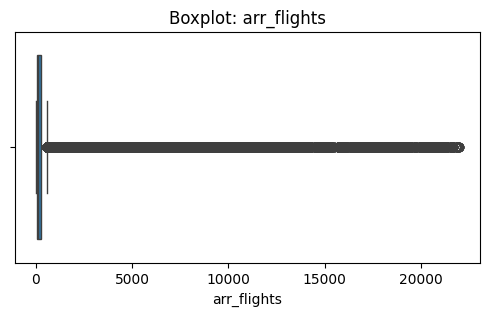

carrier_ct: Dolna granica: -14.200000405311584   Górna granica: 29.800000548362732


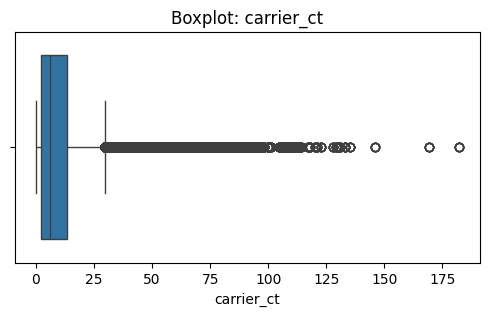

weather_ct: Dolna granica: -1.6800000071525574   Górna granica: 2.800000011920929


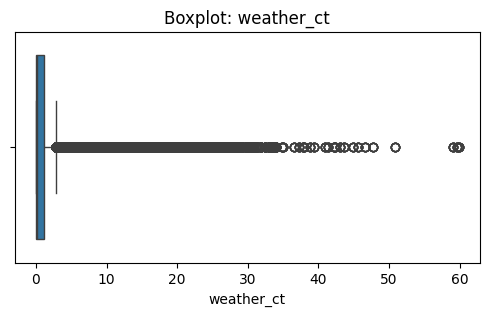

nas_ct: Dolna granica: -8.704999685287476   Górna granica: 17.174999475479126


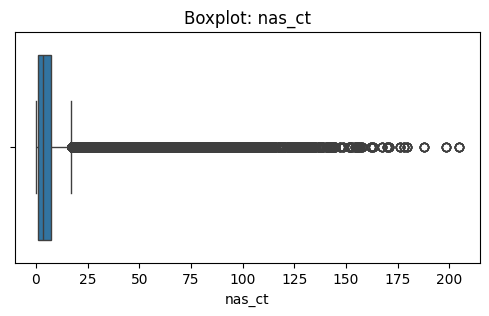

security_ct: Dolna granica: 0.0   Górna granica: 0.0


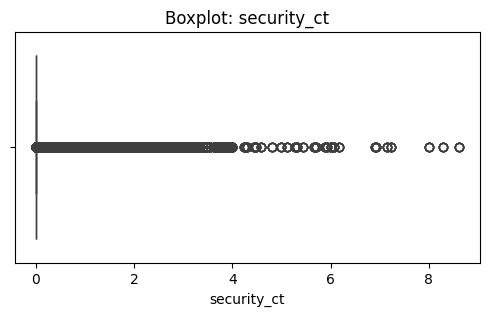

late_aircraft_ct: Dolna granica: -8.604999721050262   Górna granica: 16.714999496936798


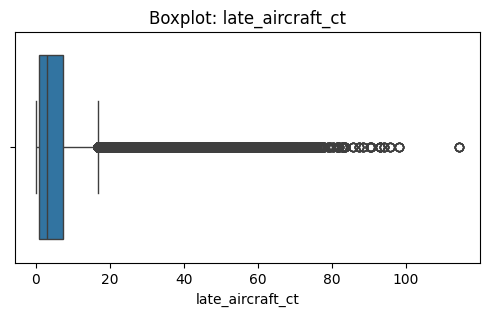

arr_cancelled: Dolna granica: -3.0   Górna granica: 5.0


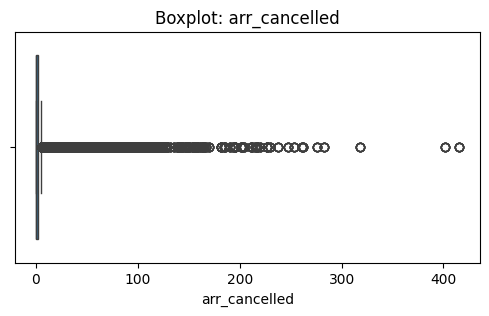

arr_diverted: Dolna granica: 0.0   Górna granica: 0.0


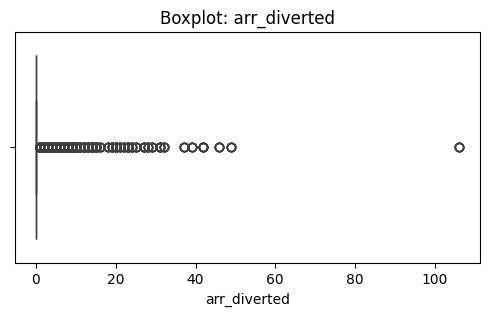

In [27]:
columns_to_check_outliers = [
    'arr_flights',
    'carrier_ct',
    'weather_ct',
    'nas_ct',
    'security_ct',
    'late_aircraft_ct',
    'arr_cancelled',
    'arr_diverted'
]

for col in columns_to_check_outliers:
    q1 = ddf[col].quantile(0.25).compute()
    q3 = ddf[col].quantile(0.75).compute()
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    print(f'{col}: Dolna granica: {lower_bound}   Górna granica: {upper_bound}')

    pandas_df = ddf[[col]].compute()
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=pandas_df, x=col)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

    ddf = ddf[(ddf[col] >= lower_bound) & (ddf[col] <= upper_bound)]

In [28]:
ddf.describe().compute()

,year,month,arr_flights,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted
count,1.148478e+06,1.148478e+06,1.148478e+06,1.148478e+06,1.148478e+06,1.148478e+06,1148478.0,1.148478e+06,1.148478e+06,1148478.0
mean,2.015110e+03,6.635589e+00,7.511958e+01,4.843593e+00,3.832681e-01,3.229988e+00,0.0,3.531816e+00,7.423320e-01,0.0
std,6.250947e+00,3.415745e+00,6.560575e+01,4.852225e+00,6.302909e-01,3.540588e+00,0.0,3.840931e+00,1.215916e+00,0.0
min,2.003000e+03,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0
25%,2.010000e+03,4.000000e+00,3.000000e+01,1.140000e+00,0.000000e+00,5.100000e-01,0.0,5.300000e-01,0.000000e+00,0.0
50%,2.016000e+03,7.000000e+00,6.000000e+01,3.410000e+00,0.000000e+00,2.040000e+00,0.0,2.160000e+00,0.000000e+00,0.0
75%,2.021000e+03,1.000000e+01,9.900000e+01,6.960000e+00,7.300000e-01,4.740000e+00,0.0,5.360000e+00,1.000000e+00,0.0
max,2.024000e+03,1.200000e+01,5.560000e+02,2.979000e+01,2.800000e+00,1.717000e+01,0.0,1.671000e+01,5.000000e+00,0.0


## Wybór istotnych cech
Utworzymy nową kolumnę o nazwie flights_without_delay, która definiujemy jako różnicę między łączną liczbą przelotów (arr_flights) a sumą zdarzeń opóźniających (opóźnienia przyczynowe, odwołania, przekierowania) Dzięki temu uzyskujemy przybliżoną wartość liczby lotów przebiegających bez problemów

Min flights_without_delay: -0.010000228881835938 s, max flights_without_delay: 549.0 s
flights_without_delay: LB: -65.47499942779541   UP: 170.48499965667725


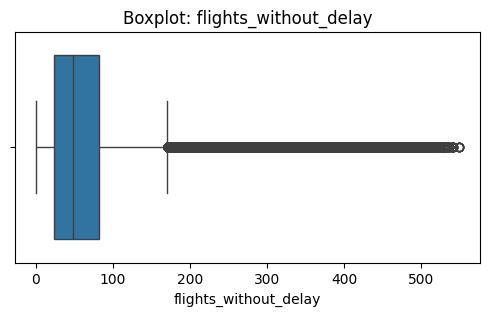

Po usunięciu outlierów - min flights_without_delay: 0.0, max flights_without_delay: 170.010009765625


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
ddf['flights_without_delay'] = ddf['arr_flights'] - (
    ddf['carrier_ct'] +
    ddf['weather_ct'] +
    ddf['nas_ct'] +
    ddf['security_ct'] +
    ddf['late_aircraft_ct'] +
    ddf['arr_cancelled'] +
    ddf['arr_diverted']
)
print(f"Min flights_without_delay: {ddf['flights_without_delay'].min().compute()} s, "
      f"max flights_without_delay: {ddf['flights_without_delay'].max().compute()} s")
ddf = ddf[ddf['flights_without_delay'] >= 0]
q1 = ddf['flights_without_delay'].quantile(0.25).compute()
q3 = ddf['flights_without_delay'].quantile(0.75).compute()
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"flights_without_delay: LB: {lower_bound}   UP: {upper_bound}")

pandas_df = ddf[['flights_without_delay']].compute()
plt.figure(figsize=(6, 3))
sns.boxplot(data=pandas_df, x='flights_without_delay')
plt.title('Boxplot: flights_without_delay')
plt.xlabel('flights_without_delay')
plt.show()

ddf = ddf[(ddf['flights_without_delay'] >= lower_bound) & (ddf['flights_without_delay'] <= upper_bound)]
print(f"Po usunięciu outlierów - min flights_without_delay: {ddf['flights_without_delay'].min().compute()}, "
      f"max flights_without_delay: {ddf['flights_without_delay'].max().compute()}")


Correlation Matrix:
                           year     month  arr_flights  carrier_ct  \
year                   1.000000 -0.042903    -0.169271   -0.185461   
month                 -0.042903  1.000000     0.044154    0.009034   
arr_flights           -0.169271  0.044154     1.000000    0.663784   
carrier_ct            -0.185461  0.009034     0.663784    1.000000   
weather_ct            -0.061319 -0.033303     0.287625    0.275165   
nas_ct                -0.221428 -0.008144     0.559696    0.457752   
security_ct                 NaN       NaN          NaN         NaN   
late_aircraft_ct      -0.083246 -0.001356     0.589996    0.521292   
arr_cancelled         -0.054625 -0.098737     0.256323    0.260888   
arr_diverted                NaN       NaN          NaN         NaN   
flights_without_delay -0.148817  0.055313     0.985985    0.568040   

                       weather_ct    nas_ct  security_ct  late_aircraft_ct  \
year                    -0.061319 -0.221428          NaN    

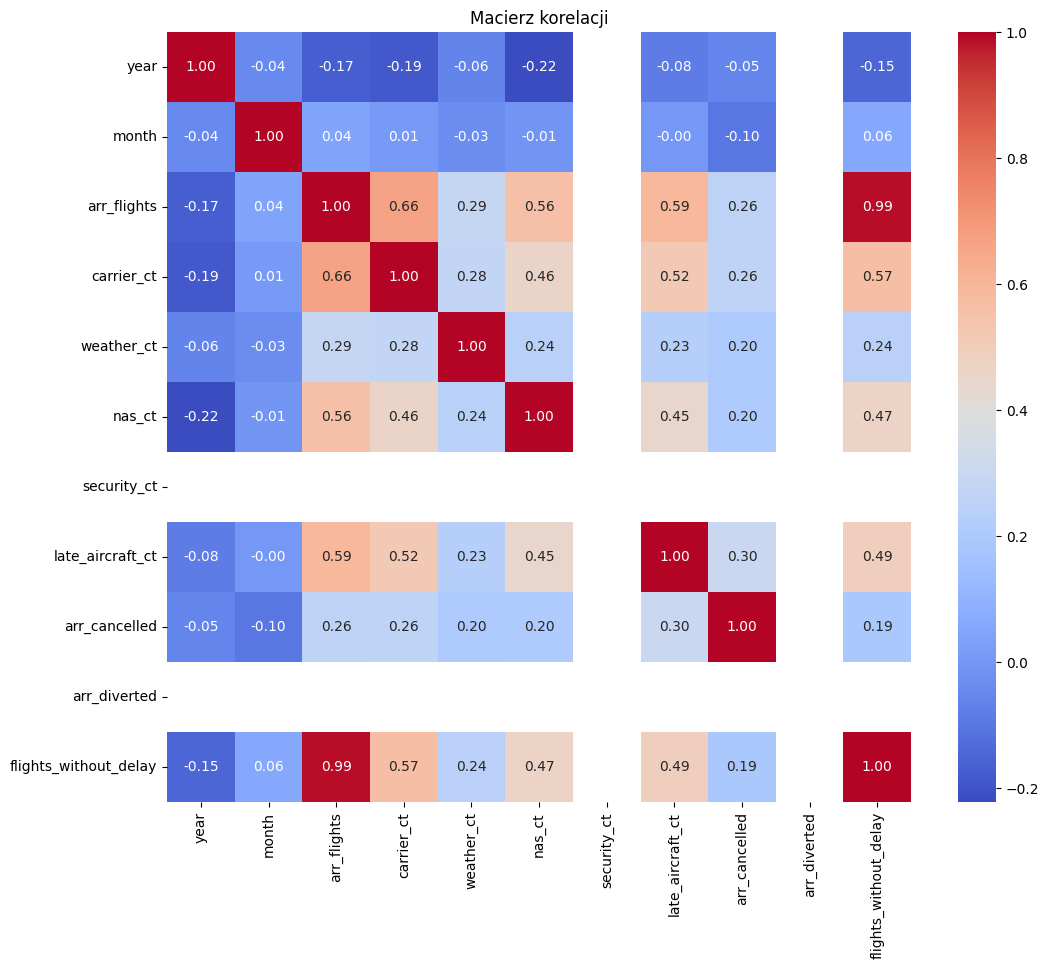

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import dask.dataframe as dd

dtypes = {
    'year': 'int16',
    'month': 'int8',
    'arr_flights': 'float32',
    'carrier_ct': 'float32',
    'weather_ct': 'float32',
    'nas_ct': 'float32',
    'security_ct': 'float32',
    'late_aircraft_ct': 'float32',
    'arr_cancelled': 'float32',
    'arr_diverted': 'float32',
    'flights_without_delay': 'float32'
}

for col, new_type in dtypes.items():
    ddf[col] = dd.to_numeric(ddf[col], errors='coerce').astype(new_type)

ddf = ddf.dropna()

numeric_ddf = ddf.select_dtypes(include=['number'])

try:
    correlation_matrix = numeric_ddf.corr().compute()
    print("\nCorrelation Matrix:")
    print(correlation_matrix)
except Exception as e:
    print(f"Błąd podczas obliczania macierzy korelacji: {e}")
    raise

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Macierz korelacji')
plt.show()


## Zapis parquet

In [31]:
import os

print(f"Finalnie liczba rekordów wynosi: {ddf.shape[0].compute()}, liczba cech {len(ddf.columns)}")

output_folder = 'processed_data'
os.makedirs(output_folder, exist_ok=True)

ddf['carrier'] = ddf['carrier'].astype(str)
ddf['airport'] = ddf['airport'].astype(str)

ddf = ddf.repartition(npartitions=10)

ddf.to_parquet(
    output_folder,
    engine='pyarrow',
    compression='snappy',
    write_metadata_file=False,
    name_function=lambda i: f"airline_data_processed_2024_{i+1:02d}.parquet"
)

print(f"Dane zostały zapisane w folderze: {output_folder}")

Finalnie liczba rekordów wynosi: 1088052, liczba cech 13
Dane zostały zapisane w folderze: processed_data


# Etap 3 - Uczenie modelu
## Spis treści
1. [Podział Danych](#podzial-danych)
2. [Definicja modelu](#definicja-modelu)
3. [Trenowanie modelu](#trenowanie-modelu)
4. [Ewaluacja modelu](#ewaluacja-modelu)
5. [Serializacja modelu](#serializacja-modelu)

## Podział danych

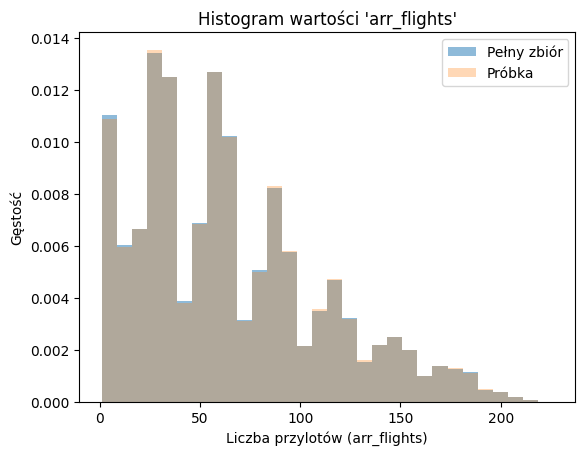

In [32]:
from sklearn.model_selection import train_test_split
import dask.array as da
from dask_ml.model_selection import GridSearchCV, train_test_split
from xgboost.dask import DaskXGBRegressor
ddf_sample = ddf.sample(frac=0.01, random_state=42)
arr_flights_full = ddf['arr_flights'].compute()

ddf_sample = ddf.sample(frac=0.1, random_state=42)  # Próbka 10% danych
arr_flights_sample = ddf_sample['arr_flights'].compute()

plt.hist(arr_flights_full, bins=30, density=True, alpha=0.5, label='Pełny zbiór')
plt.hist(arr_flights_sample, bins=30, density=True, alpha=0.3, label='Próbka')

plt.legend()
plt.title("Histogram wartości 'arr_flights'")
plt.xlabel("Liczba przylotów (arr_flights)")
plt.ylabel("Gęstość")
plt.show()

target_column = 'arr_flights'

feature_cols = [col for col in ddf_sample.columns if col != target_column]

X = ddf_sample[feature_cols].to_dask_array(lengths=True)
y = ddf_sample[target_column].to_dask_array(lengths=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
xgb_reg = DaskXGBRegressor(
    tree_method='hist',
    objective='reg:squarederror',
    random_state=42
)

param_grid = {
    'max_depth': [3, 5, 7],
    'eta': [0.01, 0.1, 0.3],
    'subsample': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'colsample_bytree': [0.5, 0.7, 0.85, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_reg,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1
)


## Trening modelu

In [41]:
from dask_ml.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
encoded_ddf_sample = ddf_sample.copy()
encoded_ddf_sample[['carrier', 'airport']] = encoder.fit_transform(encoded_ddf_sample[['carrier', 'airport']])

print("Zakodowane dane:")
print(encoded_ddf_sample[['carrier', 'airport']].head())
print(encoded_ddf_sample.dtypes)

Zakodowane dane:
       carrier airport
158924      MQ     MKE
109649      DL     ICT
2800        MQ     MYR
175809      DL     PSC
79077       MQ     MRY
year                       int16
month                       int8
carrier                   object
airport                   object
arr_flights              float32
carrier_ct               float32
weather_ct               float32
nas_ct                   float32
security_ct              float32
late_aircraft_ct         float32
arr_cancelled            float32
arr_diverted             float32
flights_without_delay    float32
dtype: object


Najlepsze parametry: {'max_depth': 7, 'learning_rate': 0.1, 'subsample': 0.9, 'min_child_weight': 5, 'colsample_bytree': 1.0}
Najlepszy MSE: 0.8388174772262573

Ważność funkcji (od najwyższej):
flights_without_delay: 0.9695
carrier_ct: 0.0124
late_aircraft_ct: 0.0101
nas_ct: 0.0050
arr_cancelled: 0.0021
weather_ct: 0.0006
airport: 0.0001
carrier: 0.0000
month: 0.0000
year: 0.0000
security_ct: 0.0000
arr_diverted: 0.0000


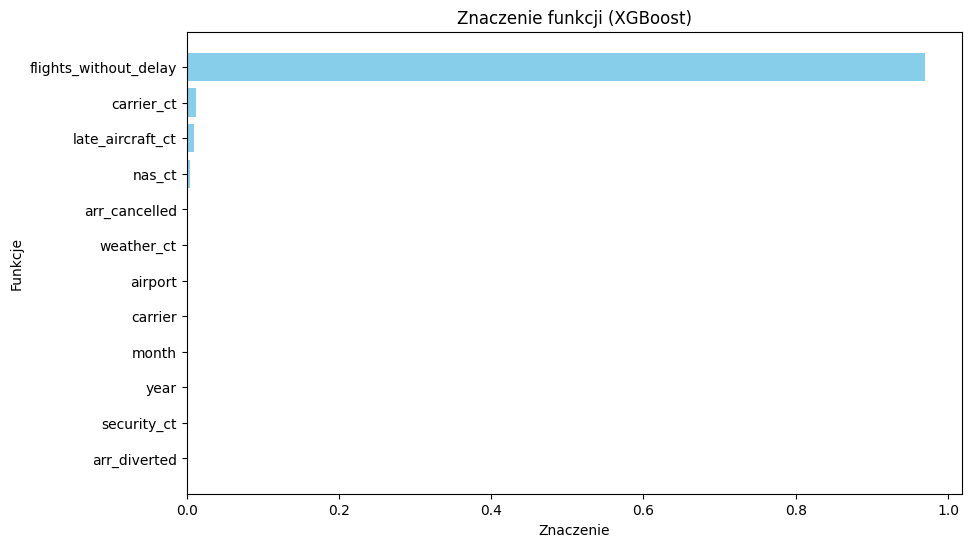

In [45]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

encoded_ddf_sample['carrier'] = encoded_ddf_sample['carrier'].astype('category')
encoded_ddf_sample['airport'] = encoded_ddf_sample['airport'].astype('category')

target_column = 'arr_flights'
feature_cols = [col for col in encoded_ddf_sample.columns if col != target_column]

X = encoded_ddf_sample[feature_cols]
y = encoded_ddf_sample[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'colsample_bytree': [0.5, 0.7, 0.85, 1.0],
    'n_estimators': [100]
}

best_score = float('inf')
best_params = None
best_model = None

for max_depth in param_grid['max_depth']:
    for learning_rate in param_grid['learning_rate']:
        for subsample in param_grid['subsample']:
            for min_child_weight in param_grid['min_child_weight']:
                for colsample_bytree in param_grid['colsample_bytree']:
                    model = XGBRegressor(
                        max_depth=max_depth,
                        learning_rate=learning_rate,
                        subsample=subsample,
                        min_child_weight=min_child_weight,
                        colsample_bytree=colsample_bytree,
                        n_estimators=100,
                        objective='reg:squarederror',
                        tree_method='hist',
                        enable_categorical=True,
                        random_state=42
                    )
                    model.fit(X_train, y_train)
                    y_pred = model.predict(X_test)
                    mse = mean_squared_error(y_test, y_pred)

                    if mse < best_score:
                        best_score = mse
                        best_params = {
                            'max_depth': max_depth,
                            'learning_rate': learning_rate,
                            'subsample': subsample,
                            'min_child_weight': min_child_weight,
                            'colsample_bytree': colsample_bytree
                        }
                        best_model = model

print(f"Najlepsze parametry: {best_params}")
print(f"Najlepszy MSE: {best_score}")

feature_importances = best_model.feature_importances_
feature_importance_map = dict(zip(feature_cols, feature_importances))
sorted_features = sorted(feature_importance_map.items(), key=lambda x: x[1], reverse=True)

print("\nWażność funkcji (od najwyższej):")
for feature, importance in sorted_features:
    print(f"{feature}: {importance:.4f}")

plt.figure(figsize=(10, 6))
plt.barh(
    [x[0] for x in sorted_features],
    [x[1] for x in sorted_features],
    color='skyblue'
)
plt.xlabel('Znaczenie')
plt.ylabel('Funkcje')
plt.title('Znaczenie funkcji (XGBoost)')
plt.gca().invert_yaxis()
plt.show()

In [57]:
encoded_ddf_sample = encoded_ddf_sample.compute()

encoded_ddf_sample['carrier'] = encoded_ddf_sample['carrier'].astype('category')
encoded_ddf_sample['airport'] = encoded_ddf_sample['airport'].astype('category')

target_column = 'arr_flights'
feature_cols = [col for col in encoded_ddf_sample.columns if col != target_column]

X = encoded_ddf_sample[feature_cols]
y = encoded_ddf_sample[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'colsample_bytree': [0.5, 0.7, 0.85, 1.0],
    'n_estimators': [100]
}

best_score = float('inf')
best_params = None
best_model = None

for max_depth in param_grid['max_depth']:
    for learning_rate in param_grid['learning_rate']:
        for subsample in param_grid['subsample']:
            for min_child_weight in param_grid['min_child_weight']:
                for colsample_bytree in param_grid['colsample_bytree']:
                    model = XGBRegressor(
                        max_depth=max_depth,
                        learning_rate=learning_rate,
                        subsample=subsample,
                        min_child_weight=min_child_weight,
                        colsample_bytree=colsample_bytree,
                        n_estimators=100,
                        objective='reg:squarederror',
                        tree_method='hist',
                        enable_categorical=True,
                        random_state=42
                    )
                    model.fit(X_train, y_train)
                    y_pred = model.predict(X_test)
                    mse = mean_squared_error(y_test, y_pred)

                    if mse < best_score:
                        best_score = mse
                        best_params = {
                            'max_depth': max_depth,
                            'learning_rate': learning_rate,
                            'subsample': subsample,
                            'min_child_weight': min_child_weight,
                            'colsample_bytree': colsample_bytree
                        }
                        best_model = model

print(f"Najlepsze parametry: {best_params}")
print(f"Najlepszy MSE: {best_score:.4f}")

y_pred_test = best_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred_test, squared=False)
print(f"RMSE na danych testowych: {rmse:.4f}")

Najlepsze parametry: {'max_depth': 7, 'learning_rate': 0.1, 'subsample': 0.9, 'min_child_weight': 5, 'colsample_bytree': 1.0}
Najlepszy MSE: 0.8155
RMSE na danych testowych: 0.9030


## Serializacja modelu

In [58]:
import time
from xgboost.dask import DaskXGBRegressor
from sklearn.metrics import mean_squared_error

X_dask = dd.from_pandas(X, npartitions=4).to_dask_array(lengths=True)
y_dask = dd.from_pandas(y, npartitions=4).to_dask_array(lengths=True)

X_train_dask, X_test_dask, y_train_dask, y_test_dask = train_test_split(X_dask, y_dask, test_size=0.2, random_state=42)

xgb_dask_reg = DaskXGBRegressor(
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    min_child_weight=best_params['min_child_weight'],
    colsample_bytree=best_params['colsample_bytree'],
    n_estimators=100,
    tree_method='hist'
)

xgb_dask_reg.fit(X_train_dask, y_train_dask)

y_pred_big = xgb_dask_reg.predict(X_test_dask).compute()
rmse_big = mean_squared_error(y_test, y_pred_big, squared=False)
print(f"RMSE na danych testowych (duży): {rmse_big:.4f} vs (mały): {rmse:.4f}")

start = time.time()
y_pred_big = xgb_dask_reg.predict(X_test_dask).compute()
end = time.time()
print(f"Czas inferencji dla xgb_dask_reg (duży): {end - start:.4f} s")

start = time.time()
y_pred_small = best_model.predict(X_test)
end = time.time()
print(f"Czas inferencji dla best_model (mały): {end - start:.4f} s")

if rmse_big <= rmse:
    xgb_dask_reg.save_model("xgb_dask_reg_model.json")
    print("Zapisano model duży jako 'xgb_dask_reg_model.json'")
else:
    best_model.save_model("xgb_best_model.json")
    print("Zapisano model mały jako 'xgb_best_model.json'")

RMSE na danych testowych (duży): 0.8720 vs (mały): 0.9030
Czas inferencji dla xgb_dask_reg (duży): 0.1808 s
Czas inferencji dla best_model (mały): 0.0808 s
Zapisano model duży jako 'xgb_dask_reg_model.json'


# Etap 4 - Deserializacja
1. [Wczytanie Modelu json](#wczytanie-modelu)
2. [Testowanie modelu](#testowanie-modelu)

## Wczytanie modelu json

In [1]:
xgb_dask_reg_loaded = DaskXGBRegressor()
xgb_dask_reg_loaded.load_model('xgb_dask_reg_model.json')

## Testowanie modelu

In [2]:
import dask.dataframe as dd
from xgboost import XGBRegressor
import numpy as np

def predict_flight_arrivals(model, year, month, carrier, airport, carrier_ct, weather_ct, nas_ct, security_ct, late_aircraft_ct, arr_cancelled, arr_diverted, flights_without_delay):
    """
    Przewiduje liczbę przylotów na podstawie wczytanego modelu i podanych parametrów.

    Args:
        model: Wcześniej wczytany model XGBoost.
        year (int): Rok.
        month (int): Miesiąc.
        carrier (int): Zakodowany przewoźnik.
        airport (int): Zakodowane lotnisko.
        carrier_ct (float): Liczba lotów przewoźnika.
        weather_ct (float): Liczba lotów opóźnionych przez pogodę.
        nas_ct (float): Liczba opóźnień związanych z ruchem lotniczym.
        security_ct (float): Liczba problemów z bezpieczeństwem.
        late_aircraft_ct (float): Liczba opóźnień spowodowanych późnym przylotem.
        arr_cancelled (float): Liczba odwołanych lotów.
        arr_diverted (float): Liczba przekierowanych lotów.
        flights_without_delay (float): Liczba lotów bez opóźnienia.

    Returns:
        float: Przewidywana liczba przylotów.
    """
    input_data = dd.from_dict({
        'year': [year],
        'month': [month],
        'carrier': [carrier],
        'airport': [airport],
        'carrier_ct': [carrier_ct],
        'weather_ct': [weather_ct],
        'nas_ct': [nas_ct],
        'security_ct': [security_ct],
        'late_aircraft_ct': [late_aircraft_ct],
        'arr_cancelled': [arr_cancelled],
        'arr_diverted': [arr_diverted],
        'flights_without_delay': [flights_without_delay]
    }, npartitions=1)

    return model.predict(input_data.compute())[0]

best_model = XGBRegressor()
best_model.save_model("xgb_best_model.model")

model = XGBRegressor()
model.load_model("xgb_best_model.model")
print("Model został wczytany pomyślnie.")

result = predict_flight_arrivals(
    model=model,
    year=2023,
    month=7,
    carrier=1,
    airport=5,
    carrier_ct=50.0,
    weather_ct=10.0,
    nas_ct=15.0,
    security_ct=0.0,
    late_aircraft_ct=5.0,
    arr_cancelled=1.0,
    arr_diverted=0.0,
    flights_without_delay=40.0
)

print(f"Przewidywana liczba przylotów: {round(result, 2)}")


NotFittedError: need to call fit or load_model beforehand